### Comparing Sacks Per Game for Edge Rushers to Draft Position

/var/folders/kd/67tgtnt11qvdxt3hrkby_8qr0000gn/T/ipykernel_65958/764979663.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=10)


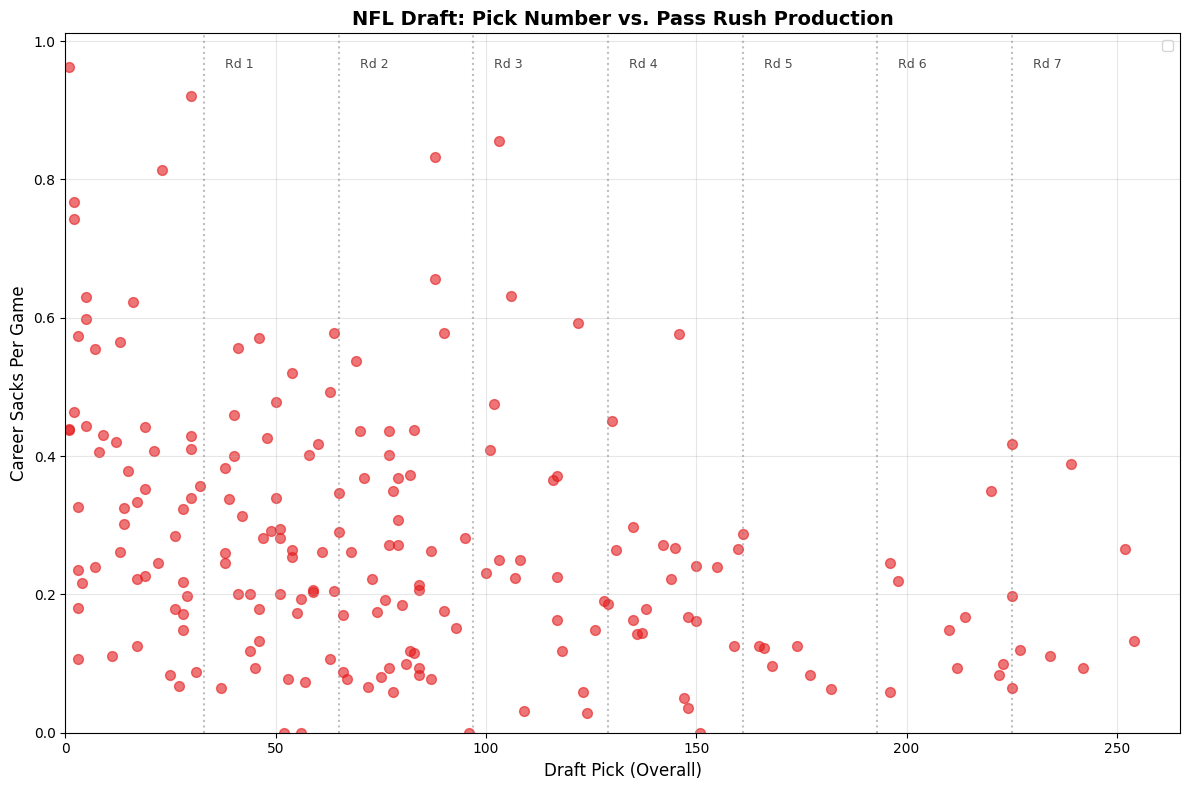


PRODUCTION BY DRAFT ROUND
----------------------------------------
             Count  Median SPG  Mean SPG  Pct > 0.3 SPG
round_group                                            
Round 1         50       0.336     0.375          0.600
Round 2         43       0.261     0.277          0.372
Round 3         45       0.231     0.275          0.356
Round 4         23       0.223     0.248          0.261
Round 5         20       0.164     0.181          0.050
Round 6          7       0.148     0.145          0.000
Round 7         12       0.126     0.194          0.250


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


DL_summary = pd.read_csv('dl_analysis_data.csv')


edge_rushers = DL_summary[DL_summary['position_group'] == 'Edge']

# Filter to drafted players only (has draft pick number)
drafted = edge_rushers[edge_rushers['overall_pick'].notna()].copy()

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Plot Edge and Interior separately
ax.scatter(
    drafted['overall_pick'], 
    drafted['sacks_per_game'],
    alpha=0.6,
    s=50,
    c='#E41A1C',
    marker='o'
)

# # Add a trend line (polynomial or lowess works well)
# z = np.polyfit(drafted['overall_pick'], drafted['sacks_per_game'], 2)
# p = np.poly1d(z)
# x_trend = np.linspace(1, 260, 100)
# ax.plot(x_trend, p(x_trend), 'k--', alpha=0.5, label='Trend (2nd order)')

# Add reference lines for draft rounds
round_boundaries = [33, 65, 97, 129, 161, 193, 225]  # Start of rounds 2-7
round_labels = ['Rd 1', 'Rd 2', 'Rd 3', 'Rd 4', 'Rd 5', 'Rd 6', 'Rd 7']
for i, boundary in enumerate(round_boundaries):
    ax.axvline(x=boundary, color='gray', linestyle=':', alpha=0.5)
    ax.text(boundary + 5, ax.get_ylim()[1] * 0.95, round_labels[i], 
            fontsize=9, alpha=0.7)

# Labels and title
ax.set_xlabel('Draft Pick (Overall)', fontsize=12)
ax.set_ylabel('Career Sacks Per Game', fontsize=12)
ax.set_title('NFL Draft: Pick Number vs. Pass Rush Production', fontsize=14, fontweight='bold')

# # Add horizontal line for median production
# median_prod = drafted['sacks_per_game'].median()
# ax.axhline(y=median_prod, color='green', linestyle='--', alpha=0.5, 
#            label=f'Median: {median_prod:.3f} sacks/game')

# # Add annotation for "steals" (late round, high production)
# steals = drafted[(drafted['overall_pick'] > 100) & (drafted['sacks_per_game'] > 0.5)]
# for _, player in steals.nlargest(5, 'sacks_per_game').iterrows():
#     ax.annotate(
#         player['Name'], 
#         (player['overall_pick'], player['sacks_per_game']),
#         xytext=(10, 5), 
#         textcoords='offset points',
#         fontsize=8,
#         alpha=0.8
#     )

# # Add annotation for "busts" (early pick, low production)
# busts = drafted[(drafted['overall_pick'] <= 32) & (drafted['sacks_per_game'] < 0.2)]
# for _, player in busts.nsmallest(5, 'sacks_per_game').iterrows():
#     ax.annotate(
#         player['Name'], 
#         (player['overall_pick'], player['sacks_per_game']),
#         xytext=(10, -10), 
#         textcoords='offset points',
#         fontsize=8,
#         alpha=0.8
#     )

ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 265)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('draft_position_vs_sacks_per_game.png', dpi=150, bbox_inches='tight')
plt.show()

# Also print summary stats by round
print("\n" + "=" * 80)
print("PRODUCTION BY DRAFT ROUND")
print("-" * 40)

drafted['round_group'] = drafted['draft_round'].apply(
    lambda x: f"Round {int(x)}" if pd.notna(x) else "Undrafted"
)

round_summary = drafted.groupby('round_group').agg({
    'sacks_per_game': ['count', 'median', 'mean', lambda x: (x >= 0.3).sum() / len(x)]
}).round(3)

round_summary.columns = ['Count', 'Median SPG', 'Mean SPG', 'Pct > 0.3 SPG']
print(round_summary)

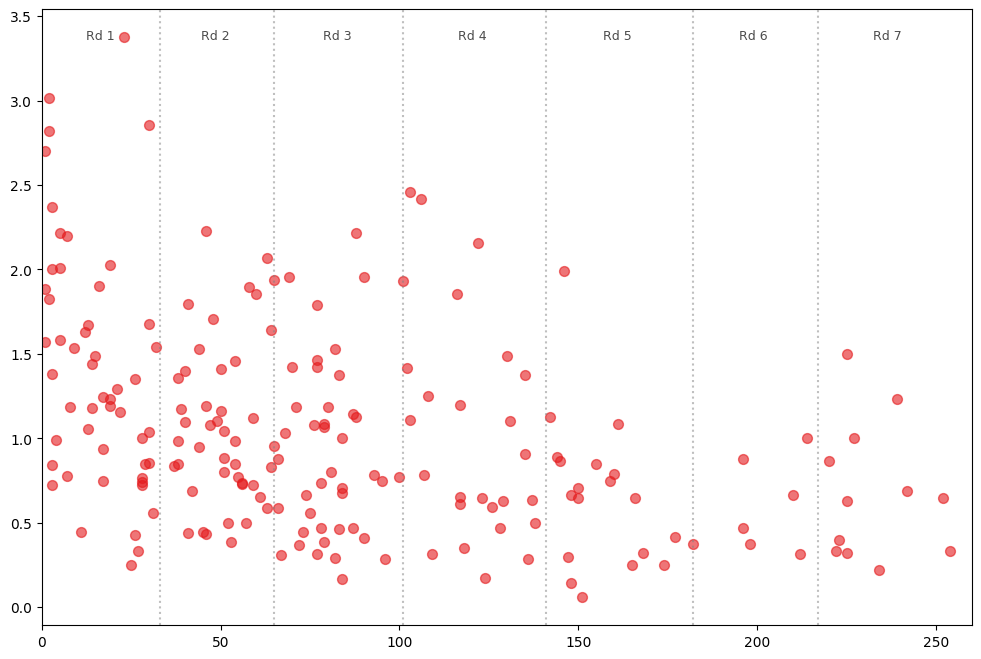

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Filter to drafted players only (has draft pick number)
drafted = edge_rushers[edge_rushers['overall_pick'].notna()].copy()

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    drafted['overall_pick'],
    drafted['pressures_per_game'],
    alpha=0.6,
    s=50,
    c='#E41A1C',
    marker='o'
)

# Add reference lines for draft rounds
round_starts = [1, 33, 65, 101, 141, 182, 217, 257]  # Including start of Round 1 and end boundary

# Add vertical lines at round boundaries, based on 2026
# Numbers vary based on comp pick
for i, boundary in enumerate(round_starts[1:-1]):  # Skip the first (1) and last (225)
    ax.axvline(x=boundary, color='gray', linestyle=':', alpha=0.5)

# Add round labels at midpoints
for i in range(7):
    start = round_starts[i]
    end = round_starts[i+1] - 1
    midpoint = (start + end) / 2
    ax.text(midpoint, ax.get_ylim()[1] * 0.95, f'Rd {i+1}', 
            fontsize=9, ha='center', alpha=0.7)

# Set x-axis limits to remove buffer
ax.set_xlim(0, 260)

plt.show()



75th percentile threshold (Edge): 0.367 sacks/game


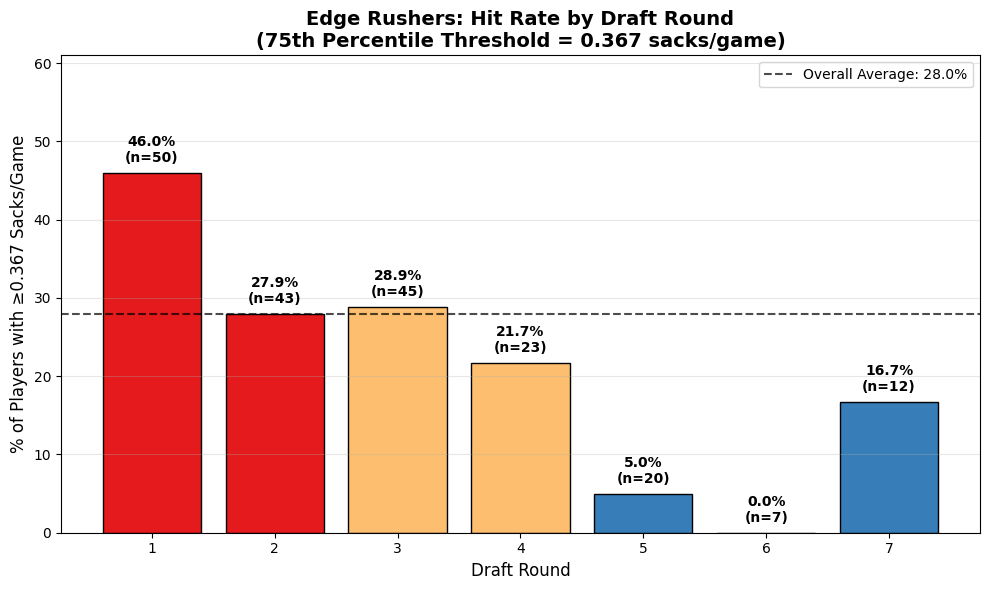


EDGE RUSHERS: HIT RATE BY ROUND
Threshold (75th percentile): 0.367 sacks/game
------------------------------------------------------------
 round  total_players  above_threshold  hit_rate
     1             50               23 46.000000
     2             43               12 27.906977
     3             45               13 28.888889
     4             23                5 21.739130
     5             20                1  5.000000
     6              7                0  0.000000
     7             12                2 16.666667
------------------------------------------------------------
Overall hit rate: 28.0% (56/200 players)


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Get the 75th percentile threshold for edge rushers
threshold_75 = edge_rushers['sacks_per_game'].quantile(0.75)
print(f"75th percentile threshold (Edge): {threshold_75:.3f} sacks/game")

# Filter to drafted edge rushers only
drafted_edge = edge_rushers[edge_rushers['draft_round'].notna()].copy()

# Calculate hit rate by round
round_stats = []
for round_num in sorted(drafted_edge['draft_round'].unique()):
    round_players = drafted_edge[drafted_edge['draft_round'] == round_num]
    total_players = len(round_players)
    above_threshold = len(round_players[round_players['sacks_per_game'] >= threshold_75])
    hit_rate = (above_threshold / total_players) * 100
    
    round_stats.append({
        'round': int(round_num),
        'total_players': total_players,
        'above_threshold': above_threshold,
        'hit_rate': hit_rate
    })

round_stats_df = pd.DataFrame(round_stats)

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    round_stats_df['round'], 
    round_stats_df['hit_rate'],
    color=['#E41A1C' if r <= 2 else '#FDBF6F' if r <= 4 else '#377EB8' for r in round_stats_df['round']],
    edgecolor='black',
    linewidth=1
)

# Add value labels on top of each bar
for bar, hit_rate, total in zip(bars, round_stats_df['hit_rate'], round_stats_df['total_players']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{hit_rate:.1f}%\n(n={total})',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Add horizontal line for overall average hit rate
overall_hit_rate = (len(drafted_edge[drafted_edge['sacks_per_game'] >= threshold_75]) / len(drafted_edge)) * 100
ax.axhline(y=overall_hit_rate, color='black', linestyle='--', alpha=0.7, 
           label=f'Overall Average: {overall_hit_rate:.1f}%')

# Labels and title
ax.set_xlabel('Draft Round', fontsize=12)
ax.set_ylabel(f'% of Players with ≥{threshold_75:.3f} Sacks/Game', fontsize=12)
ax.set_title(f'Edge Rushers: Hit Rate by Draft Round\n(75th Percentile Threshold = {threshold_75:.3f} sacks/game)', 
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(round_stats_df['hit_rate']) + 15)
ax.set_xticks(round_stats_df['round'])
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('edge_hit_rate_by_round.png', dpi=150, bbox_inches='tight')
plt.show()

# Print detailed stats
print("\n" + "=" * 60)
print("EDGE RUSHERS: HIT RATE BY ROUND")
print("=" * 60)
print(f"Threshold (75th percentile): {threshold_75:.3f} sacks/game")
print("-" * 60)
print(round_stats_df.to_string(index=False))
print("-" * 60)
print(f"Overall hit rate: {overall_hit_rate:.1f}% ({len(drafted_edge[drafted_edge['sacks_per_game'] >= threshold_75])}/{len(drafted_edge)} players)")

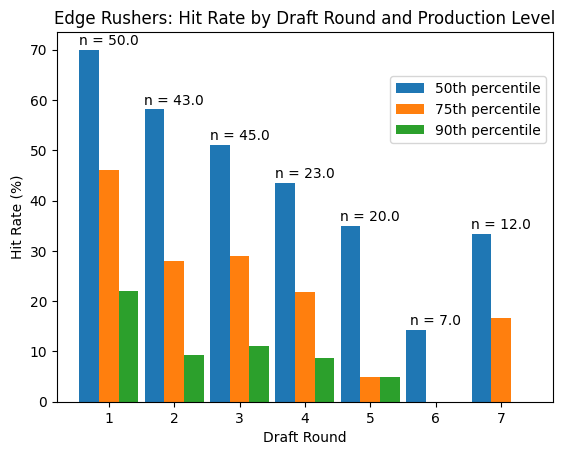

50% Stats
 round  total_players  above_threshold  hit_rate
     1             50               35 70.000000
     2             43               25 58.139535
     3             45               23 51.111111
     4             23               10 43.478261
     5             20                7 35.000000
     6              7                1 14.285714
     7             12                4 33.333333
75% Stats
 round  total_players  above_threshold  hit_rate
     1             50               23 46.000000
     2             43               12 27.906977
     3             45               13 28.888889
     4             23                5 21.739130
     5             20                1  5.000000
     6              7                0  0.000000
     7             12                2 16.666667
90% Stats
 round  total_players  above_threshold  hit_rate
     1             50               11 22.000000
     2             43                4  9.302326
     3             45                5 

<Figure size 640x480 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

drafted_edge = edge_rushers[edge_rushers['draft_round'].notna()].copy()

threshold_50 = edge_rushers['sacks_per_game'].quantile(.50)
threshold_75 = edge_rushers['sacks_per_game'].quantile(.75)
threshold_90 = edge_rushers['sacks_per_game'].quantile(.90)

# players above the 75% threshold
above = drafted_edge['sacks_per_game'] >= threshold_75

hit_50 = []
hit_75 = []
hit_90 = []

for round_num in range(1,8):
    current = drafted_edge['draft_round'] == round_num
    round_players = drafted_edge[current]
    round_total = len(drafted_edge[current])

    # calculate percetage hitting each threshold per round
    hit_threshold_50_rate = (round_players['sacks_per_game'] >= threshold_50).mean() * 100
    hit_threshold_50_count = len(round_players[round_players['sacks_per_game'] >= threshold_50])
    hit_threshold_75_rate = (round_players['sacks_per_game'] >= threshold_75).mean() * 100
    hit_threshold_75_count = len(round_players[round_players['sacks_per_game'] >= threshold_75])
    hit_threshold_90_rate = (round_players['sacks_per_game'] >= threshold_90).mean() * 100
    hit_threshold_90_count = len(round_players[round_players['sacks_per_game'] >= threshold_90])



    hit_50.append({
        'round': int(round_num),
        'total_players': round_total,
        'above_threshold': hit_threshold_50_count,
        'hit_rate': hit_threshold_50_rate
    })
    hit_75.append({
        'round': int(round_num),
        'total_players': round_total,
        'above_threshold': hit_threshold_75_count,
        'hit_rate': hit_threshold_75_rate
    })
    hit_90.append({
        'round': int(round_num),
        'total_players': round_total,
        'above_threshold': hit_threshold_90_count,
        'hit_rate': hit_threshold_90_rate
    })
    # total players in a round

h50_df = pd.DataFrame(hit_50)
h75_df = pd.DataFrame(hit_75)
h90_df = pd.DataFrame(hit_90)

rounds = list(h50_df['round'])
x = np.arange(len(rounds))
width = 0.3

plt.bar(x - width, h50_df['hit_rate'], width, label='50th percentile')
plt.bar(x, h75_df['hit_rate'], width, label='75th percentile')
plt.bar(x + width, h90_df['hit_rate'], width, label='90th percentile')


# Change x-axis labels to round numbers
plt.xticks(x, rounds)
plt.xlabel('Draft Round')
plt.ylabel('Hit Rate (%)')
plt.title('Edge Rushers: Hit Rate by Draft Round and Production Level')
plt.legend(bbox_to_anchor=(1, .9), loc='upper right')


# adding total player count per round
for round_num in range(1,8):
    x_position = round_num - 1
    y_position = h50_df.iloc[round_num - 1]['hit_rate'] + 1
    count = h50_df.iloc[round_num - 1]['total_players']
    plt.text(x_position, y_position, f"n = {count}", ha='center')

plt.show()

print("50% Stats")
print(h50_df.to_string(index=False))
print("75% Stats")
print(h75_df.to_string(index=False))
print("90% Stats")
print(h90_df.to_string(index=False))


plt.savefig('edge_hit_rate_by_round.png', dpi=150, bbox_inches='tight')


***
### Edge NFL Sack Production Takeaways

**1. There are two big cliffs for sack production: Round 1 and Round 4.** After round one, the numbers are staggeringly different. At the 50th percentile, it drops from a 70% hit rate to 58% in the next highest round. At the 75th percentile, it drops from 46% to nearly 29%. And for 90 percentile, it drops from 22% to around 11%. Needless to say, 1st round evaluations on edge rushers have a much higher success rate than any other round, based on sack per game production. The round 4 cliff, while not as prominent, is still noticible. The respective dropsoffs from worse round 1-4 hit percentage to best round 5-7 hit percentage is 8%, 5%, and 3%, with rounds 6 and 7 producing no 90th percentile sack production, and a dismal 3 total players in rounds 5 through 7 with a 75th or higher percentile in sack production.

**2. Rounds 2 and 3 produce very similar results.** In the years we have data on (2018 to 2025 NFL Stats, players drafted from 2013 to now), there have been 43 players listed as edge in the second round and 45 in the third. While that number is already remarkably similar, the results that were found on sack per game production were even more shocking. While round two boasts a 7% lead in terms of hit rate in the 50th percentile (meaning there are less busts in round two than there are in round three), the numbers in the 75th percentile and 90th percentile actually slightly favor round three, leading each category by 1% and 2%. This means edge rushers are slightly more likely to be higher end sack producers in round three than they are in round too, but they also have a bigger chance of busting. This could possibly be attributed to bigger swings in round three. Maybe edge rushers with better measurables but less college production are given a chance in round three while more proven staticians are given the nod in round two. 

**3. Round 6 is a dud.** While it is hard to fully take a lot away from round six, because our data shows only seven drafted players in this time frame, there has been very little to be impressed by in this round. Out of the seven players, only one has been above the 50 percentile sack production, while none have been above 75 or 90 percentile. Our data doesn't account for all players, but it accounts for players who have put up enough meaningful stats in the NFL. This means that the percentages of round six duds would be even worse if it had accounted for every single player drafted in this round. 

**4. Round 7 and Round 5 have found similar production.** Rounds five through seven also produce small sample sizes (20 and 12 players), again because of the number of players throughout these rounds who don't produce anything. Given that there are nearly double the players in round seven in our sample size as round six, and nearly triple the players in round 5 in our sample size as opposed to round six, we can take something away from there: there are simply more players that see the field in rounds five and seven than there are in round six. As far as 50th percentile and above production, that's where our data comes in. While there is a limited number of both fifth and seventh rounders that hit the 50th percentile mark, the numbers are very close, at 35% in round five and 33.3% in round seven. The 75th percentile numbers, while still small, favor round seven, with 16.7% of players hitting that mark and only 5% hitting it in round 5. That player in round 5? Matthew Judon, who also hits the 90th percentile mark, the only player in either of the two rounds to do so.  

**The bottom line:** 

***